In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
work_path = "M:/1confiProj/"
os.chdir(work_path)
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from scripts.experiments import ModelEvaluator, Experiment
from scripts.modelClassGPU import ConfiModel

device is : cpu


In [5]:
sub_id = 2
m_id = 1
ev = ModelEvaluator('MNLE_test')

# aggreagte all the subjects
df_sim = pd.DataFrame()
df_sim_sub = ev.get_model_prediction(m_id, sub_id)
df_sim_sub['model_id'] = m_id

df_beh = ev.organize_sim_data(ev.exp.get_beh_data(sub_id, MNLE=False),sub_id)

In [3]:
df_sim_sub.head()

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,bias,flipBias,abs_delta_VA,CISize_zscore,model_id
0,-10.0,-10.0,1.0,1.0,-8.608948,4.740775,1.0,78.0,2,0.0,High,1.391052,1.391052,0.0,-0.745932,1
1,-10.0,-10.0,1.0,1.0,-8.039296,6.494924,1.0,73.0,2,0.0,High,1.960704,1.960704,0.0,-0.192701,1
2,-10.0,-10.0,1.0,1.0,-8.613113,7.017496,1.0,73.0,2,0.0,High,1.386887,1.386887,0.0,-0.027890,1
3,-10.0,-10.0,1.0,1.0,-5.807845,8.433778,2.0,60.0,2,0.0,High,4.192155,4.192155,0.0,0.418783,1
4,-10.0,-10.0,1.0,1.0,-7.515041,7.679839,1.0,45.0,2,0.0,High,2.484959,2.484959,0.0,0.181002,1


In [7]:
df_beh.head()

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,bias,flipBias,abs_delta_VA
0,5.0,-10.0,1.0,1.0,-4.93,4.69,1.0,20.0,2,-15.0,High,-9.93,9.93,15.0
1,-10.0,10.0,1.0,1.0,4.93,4.46,2.0,41.0,2,20.0,High,14.93,14.93,20.0
2,-5.0,-10.0,1.0,1.0,-5.94,5.56,1.0,39.0,2,-5.0,High,-0.94,0.94,5.0
3,-5.0,5.0,1.0,1.0,4.38,2.01,1.0,78.0,2,10.0,High,9.38,9.38,10.0
4,-5.0,-5.0,1.0,1.0,-3.82,2.91,1.0,88.0,2,0.0,High,1.18,1.18,0.0


In [71]:
# prepare plot data
#1. filter the data before plotting - auditory and which visual reliability - high
df_plot = df_sim.loc[df_sim.blockType == 1, :]
nPnts = 34
df_plot_filterd = df_plot.groupby(['sub_id', 'model_id', 'AudLoc', 'VisLoc', 'VisRel']).head(nPnts).reset_index(drop=True)

#according to David's logic, first make the confLevel from common and separate sources with different dign (but is it necessary?)
df_plot_filterd.loc[df_plot_filterd.Sources==1, 'ConfLevel'] = -1 * df_plot_filterd.loc[df_plot_filterd.Sources==1, 'ConfLevel']

sorted_by = 'audbias'
# first sort the data according to either auditory spatial bias or CI size
if sorted_by == 'audbias':
    df_plot_filterd = df_plot_filterd.sort_values(by = ['sub_id', 'model_id', 'AudLoc', 'VisLoc', 'VisRel', 'flipBias'], ascending = True).reset_index(drop = True)
elif sorted_by == 'ci':
    df_plot_filterd = df_plot_filterd.sort_values(by = ['sub_id', 'model_id', 'AudLoc', 'VisLoc', 'VisRel', 'CISize'], ascending = True).reset_index(drop = True)
elif sorted_by == 'c':
    df_plot_filterd = df_plot_filterd.sort_values(by = ['sub_id', 'model_id', 'AudLoc', 'VisLoc', 'VisRel', 'ConfLevel'], ascending = True).reset_index(drop = True)

df_plot_filterd['TrialNrOrdered'] = np.tile(np.arange(1, nPnts+1), df_plot_filterd.shape[0]//nPnts)

#avergage across subjects
dfAggAud = df_plot_filterd.groupby(['model_id', 'abs_delta_VA', 'VisRel', 'TrialNrOrdered'])[['flipBias', 'CISize', 'Sources', 'ConfLevel']].mean().reset_index()
dfAggAud['ConfLevel'] = abs(dfAggAud['ConfLevel'])
dfAggAud['ConfLevel'] = round(dfAggAud['ConfLevel'])

# according to David's logic, reassign the common source judgement based on mean Sources
dfAggAud.loc[dfAggAud['Sources']-1<=0.5, 'Sources'] = 1
dfAggAud.loc[dfAggAud['Sources']-1>0.5, 'Sources'] = 2
dfAggAud.head()

,model_id,abs_delta_VA,VisRel,TrialNrOrdered,flipBias,CISize,Sources,ConfLevel
0,1,0.0,1.0,1,-4.856097,7.591974,2.0,17.0
1,1,0.0,1.0,2,-3.499040,9.101561,2.0,0.0
2,1,0.0,1.0,3,-2.761626,6.001152,1.0,38.0
3,1,0.0,1.0,4,-2.545623,7.193397,1.0,17.0
4,1,0.0,1.0,5,-2.277964,6.534974,2.0,1.0


In [72]:
# beh data 
def beh_data(data_path, sub_lst, sorted_by):
    dfAllSub = pd.read_csv(os.path.join(data_path, 'BlockACMB.csv'))
    dfAllSubAud = dfAllSub.loc[(dfAllSub.blockType ==1) & (dfAllSub.sub_id.isin(sub_lst))]# select the auditory blocks
    #dfAllSubAud.loc[:,'delta_AV'] = dfAllSubAud.loc[:, 'AudLoc'] - dfAllSubAud.loc[:, 'VisLoc']
    #dfAllSubAud.columns
    #first a quick analysis, distribution of number of avaialble trials for each combinitations
    #cntTrial = dfAllSubAud.groupby(['sub_id', 'AudLoc', 'VisLoc', 'VisRel'])['BlockNr'].count()
    #cntTrial.value_counts() # mostly the trial recur 36 times
    #cntTrial.describe() # for each sub and each AV location/reliability combos, min 34 occurence.
    nPnts = 34
    dfAllSubAud_filterd = dfAllSubAud.groupby(['sub_id', 'AudLoc', 'VisLoc', 'VisRel']).head(nPnts).reset_index(drop=True)
    dfAllSubAud_filterd.loc[dfAllSubAud_filterd.Sources==1, ['ConfLevel', 'ConfLevelNorm']] = -1 * dfAllSubAud_filterd.loc[dfAllSubAud_filterd.Sources==1, ['ConfLevel', 'ConfLevelNorm']]

    #sorted_by = 'audbias'
    # first sort the data according to either auditory spatial bias or CI size
    if sorted_by == 'audbias':
        dfAllSubAud_filterd = dfAllSubAud_filterd.sort_values(by = ['sub_id', 'AudLoc', 'VisLoc', 'VisRel', 'flipBias'], ascending = True).reset_index(drop = True)
    elif sorted_by == 'ci':
        dfAllSubAud_filterd = dfAllSubAud_filterd.sort_values(by = ['sub_id', 'AudLoc', 'VisLoc', 'VisRel', 'CISize'], ascending = True).reset_index(drop = True)
    elif sorted_by == 'c':
        dfAllSubAud_filterd = dfAllSubAud_filterd.sort_values(by = ['sub_id', 'AudLoc', 'VisLoc', 'VisRel', 'ConfLevel'], ascending = True).reset_index(drop = True)

    dfAllSubAud_filterd['TrialNrOrdered'] = np.tile(np.arange(1, nPnts+1), dfAllSubAud_filterd.shape[0]//nPnts)

    #according to David's logic, first make the confLevel from common and separate sources with different dign (but is it necessary?)
    
    #avergage across subjects
    dfAggAud = dfAllSubAud_filterd.groupby([ 'abs_delta_VA', 'VisRel', 'TrialNrOrdered'])[['flipBias', 'CISize', 'Sources', 'ConfLevel', 'ConfLevelNorm']].mean().reset_index()
    dfAggAud[['ConfLevel', 'ConfLevelNorm']] = abs(dfAggAud[['ConfLevel', 'ConfLevelNorm']])
    dfAggAud['ConfLevel'] = round(dfAggAud['ConfLevel'])

    # according to David's logic, reassign the common source judgement based on mean Sources
    dfAggAud.loc[dfAggAud['Sources']-1<=0.5, 'Sources'] = 1
    dfAggAud.loc[dfAggAud['Sources']-1>0.5, 'Sources'] = 2
    return dfAggAud

df_beh = beh_data('P:/3026008.02/AllData', sub_lst, sorted_by)
df_beh['model_id']=0
df_beh.head()
sub_id = 25
#df_beh = df_beh.loc[df_beh.sub_id.isin(sub_lst), :].reset_index(drop=True)
#dfAggAud = df_plot_filterd.loc[df_plot_filterd.sub_id == sub_id, :].reset_index(drop=True)

# agg plot

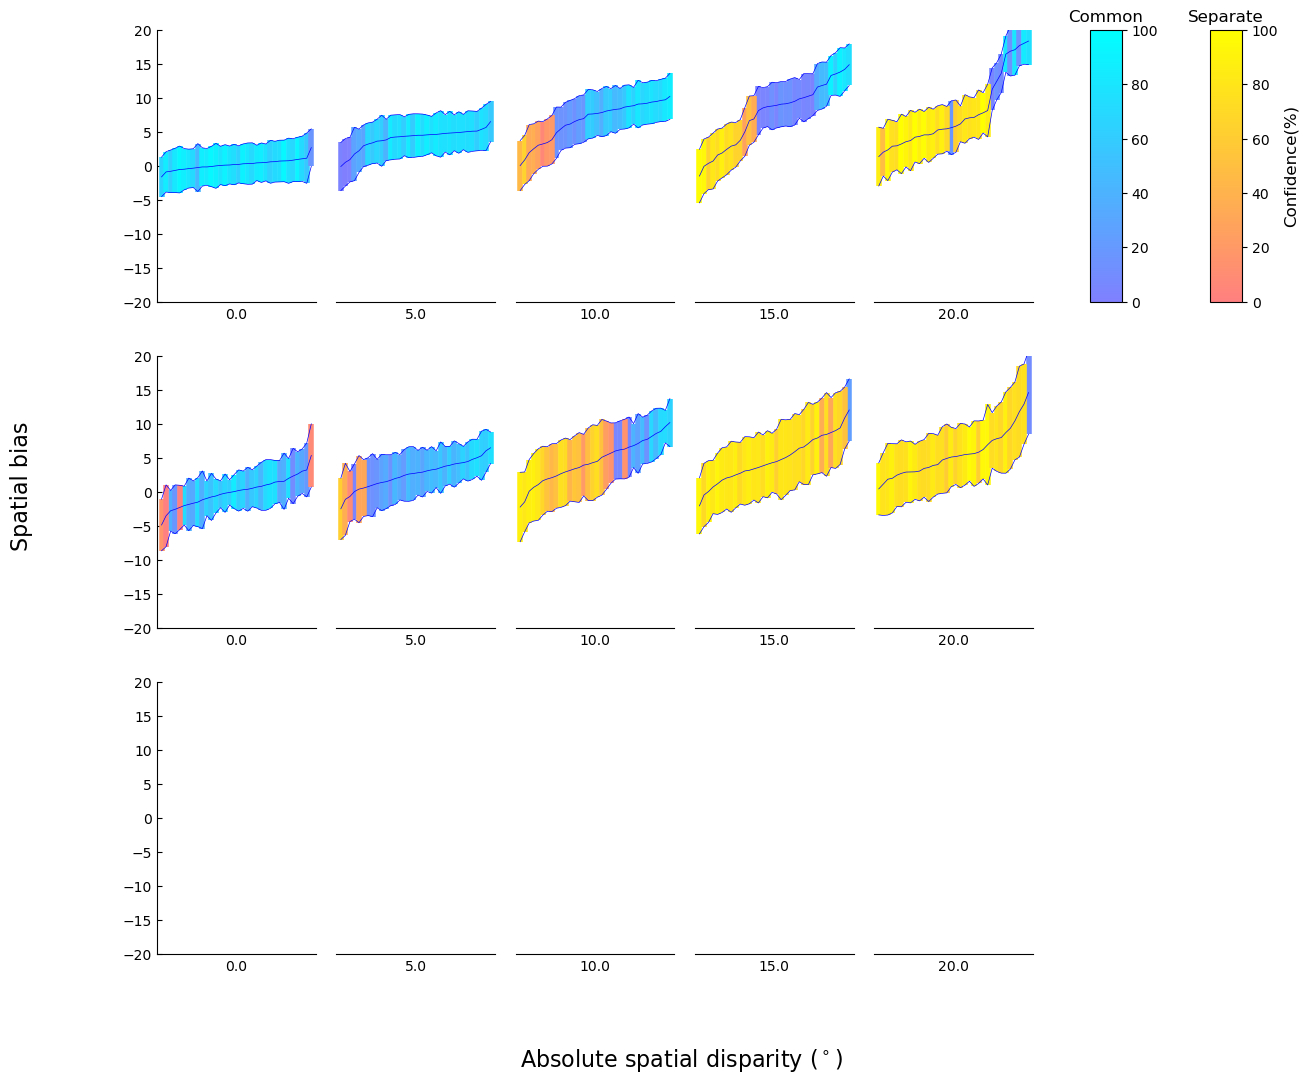

In [73]:
from utils.help_function import *
###################
####### Plot ######
###################
# Define two colormaps - shared
cmap_com = LinearSegmentedColormap.from_list('common', [[0.50 ,0.50 ,1.00], [0.00 ,1.00 ,1.00]])  
cmap_sep = LinearSegmentedColormap.from_list('separate', [[1.00 ,0.50 ,0.50], [1.00 ,1.00 ,0.00]])  
norm = plt.Normalize(0, 100)
# the audiovisual grid 
del_lst = dfAggAud.abs_delta_VA.unique()
Alocs = [-10, -5, 0, 5, 10]
Vlocs = [10, 5, 0, -5, -10]
visrel_map = {1:"High", 2:"Low"}

rel = 1  #Visual reliability level ('1' = high reliability [2 SD], '2' = low reliability [14 SD])

#plot function
def plot1AVpair(dfAggAud, axs, i, mid=0, smooth=0):
    
    data = dfAggAud[(dfAggAud.abs_delta_VA== del_lst[i]) & (dfAggAud.VisRel== rel) & (dfAggAud.model_id==mid)].reset_index(drop = True)
    ax = axs[i]
    
    if smooth == 0:
        # Create color mappings
        com_colors = cmap_com(norm(data.loc[data.Sources==1, 'ConfLevel']))
        sep_colors = cmap_sep(norm(data.loc[data.Sources==2, 'ConfLevel']))
    else:
        # add smoothing colors
        sigma = 0.5  #larger = more smoothing
        smoothed_com_conf = gaussian_filter1d(data.loc[data.Sources_new == 1, 'ConfLevel'], sigma)
        smoothed_sep_conf = gaussian_filter1d(data.loc[data.Sources_new == 2, 'ConfLevel'], sigma)
        # Create color mappings with smoothed confidence levels
        com_colors = cmap_com(norm(smoothed_com_conf))
        sep_colors = cmap_sep(norm(smoothed_sep_conf))
    
    # Prepare CI bar 
    com_segments = [
        [[x, y - err / 2], [x, y + err / 2]]  # Bottom to top segment
        for x, y, err in data.loc[data['Sources'] == 1, ['TrialNrOrdered', 'flipBias', 'CISize']].values
    ]
    sep_segments = [
        [[x, y - err / 2], [x, y + err / 2]]  # Bottom to top segment
        for x, y, err in data.loc[data['Sources'] == 2, ['TrialNrOrdered', 'flipBias', 'CISize']].values
    ]
    
    # Create two LineCollections for different probability groups
    com_collection = LineCollection(com_segments, colors=com_colors, linewidths=4)
    sep_collection = LineCollection(sep_segments, colors=sep_colors, linewidths=4)
   
    # Add two sets of CI bars
    ax.add_collection(com_collection)
    ax.add_collection(sep_collection)
    
    # add three lines: the response location, the top and bottom CI
    ax.plot(data['TrialNrOrdered'], data['flipBias'], color = 'b', lw = 0.5)
    ax.plot(data['TrialNrOrdered'], data['flipBias']+data['CISize']/2, color = 'b', lw = 0.5)
    ax.plot(data['TrialNrOrdered'], data['flipBias']-data['CISize']/2, color = 'b', lw = 0.5)

    #clean axes
    clean_axs(ax, 10)
    ax.set_xticks(np.arange(0, nPnts + 1, step=10))  
    ax.set_xlim(0, nPnts + 1)  
    ax.set_ylim(-20, 20)
    


# Plot
#fig, axs = plt.subplots(figsize=(12, 12), ncols = 6, nrows = 5, sharey=True, width_ratios=[1, 1, 1, 1, 1, 0.2])
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, len(del_lst)+4, width_ratios=[1, 1, 1, 1, 1, 0.1, 0.2, 0.3, 0.2], figure=fig)

# Create subplots for data
axs_beh = [fig.add_subplot(gs[0, col]) for col in range(len(del_lst))] 
axs_beh = np.array(axs_beh)

for i in np.arange(len(del_lst)):
    plot1AVpair(df_beh, axs_beh, i)
    axs_beh[i].set_xticks([])
    axs_beh[i].set_xlabel(del_lst[i])

# Create subplots for data
axs_m1 = [fig.add_subplot(gs[1, col]) for col in range(len(del_lst))] 
axs_m1 = np.array(axs_m1)

for i in np.arange(len(del_lst)):
    plot1AVpair(dfAggAud, axs_m1, i, 1)
    axs_m1[i].set_xticks([])
    axs_m1[i].set_xlabel(del_lst[i])

axs_m2 = [fig.add_subplot(gs[2, col]) for col in range(len(del_lst))] 
axs_m2 = np.array(axs_m2)

for i in np.arange(len(del_lst)):
    plot1AVpair(dfAggAud, axs_m2, i, 2)
    axs_m2[i].set_xticks([])
    axs_m2[i].set_xlabel(del_lst[i])

# # Add two colorbars
cbar_ax_com = fig.add_subplot(gs[0, len(del_lst)+1]) 
cbar_ax_sep = fig.add_subplot(gs[0, len(del_lst)+3]) 
sm_com = plt.cm.ScalarMappable(cmap=cmap_com, norm=norm)
cbar_com = plt.colorbar(sm_com, cax=cbar_ax_com)
#cbar_com.set_label("Confidence(%)")
cbar_com.ax.set_title("Common", fontsize=12)
sm_sep = plt.cm.ScalarMappable(cmap=cmap_sep, norm=norm)
cbar_sep = plt.colorbar(sm_sep, cax=cbar_ax_sep)
cbar_sep.set_label("Confidence(%)", fontsize=12)
cbar_sep.ax.set_title("Separate", fontsize=12)
fig.supxlabel('Absolute spatial disparity ($^\circ$)', fontsize=16)
fig.supylabel('Spatial bias', fontsize=16)
for i in np.arange(1, len(del_lst)):
    axs_m1[i].set_yticks([])
    axs_m1[i].spines['left'].set_visible(False)
    axs_m2[i].set_yticks([])
    axs_m2[i].spines['left'].set_visible(False)
    axs_beh[i].set_yticks([])
    axs_beh[i].spines['left'].set_visible(False)
    
#plt.title(f"Visual reliability level: {visrel_map[rel]}")
#plt.savefig(os.path.join('./plots', 'model_prediction_sortby_' + sorted_by + '_Vreli_' + str(rel) + '.png'), dpi = 300)
plt.show()


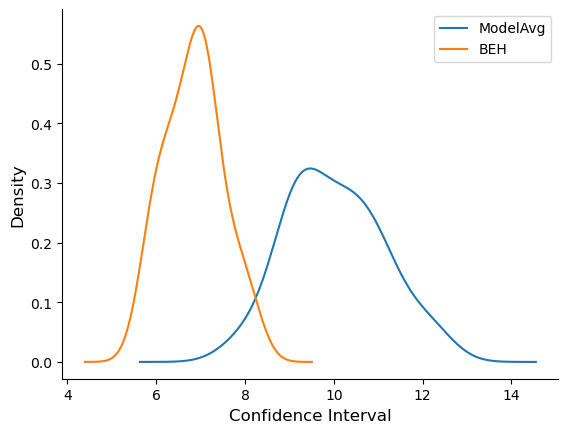

In [79]:
# distribution plot for CIsize
import matplotlib.pyplot as plt
import pandas as pd
i=3
rel = 1
dfAggAud.loc[(dfAggAud.model_id==1) & (dfAggAud.VisRel==rel) & (dfAggAud.abs_delta_VA== del_lst[i]), 'CISize'].plot(kind='density', label = 'ModelAvg')
#dfAggAud.loc[(dfAggAud.model_id==2) & (dfAggAud.VisRel==rel), 'CISize'].plot(kind='density', label = 'ModelSel')
df_beh.loc[(df_beh.VisRel==rel) & (df_beh.abs_delta_VA==del_lst[i]), 'CISize'].plot(kind='density', label = 'BEH')
plt.xlabel('Confidence Interval', fontsize = 12)
plt.ylabel('Density', fontsize = 12)
axs=plt.gca()
axs.spines[['top', 'right']].set_visible(False)
plt.legend()
plt.show()


In [75]:
df_beh

,abs_delta_VA,VisRel,TrialNrOrdered,flipBias,CISize,Sources,ConfLevel,ConfLevelNorm,model_id
0,0,1,1,-1.622,5.816,1.0,65.0,53.2,0
1,0,1,2,-0.888,5.946,1.0,85.0,72.8,0
2,0,1,3,-0.796,6.262,1.0,62.0,44.0,0
3,0,1,4,-0.664,6.530,1.0,82.0,70.6,0
4,0,1,5,-0.532,6.894,1.0,93.0,83.0,0
...,...,...,...,...,...,...,...,...,...
335,20,2,30,6.070,7.485,2.0,100.0,91.0,0
336,20,2,31,7.590,7.275,2.0,61.0,44.0,0
337,20,2,32,8.985,8.970,2.0,36.0,16.0,0
338,20,2,33,16.320,8.305,1.0,72.0,60.0,0


In [76]:
del_lst

array([ 0.,  5., 10., 15., 20.], dtype=float32)